# **DL(MLP)** 이진 분류 문제
- 전체 흐름
  1. 데이터 전처리
      - 모델이 이해할 수 있게 데이터 준비
      - 결측치 처리 / one-hot encoding / 정규화 StandardScaler
  2. 모델 생성 (MLP)
      - dense층 : 특징 조합해서 패턴 학습
  3. 모델 설정 (compile)
      - 어떻게 학습할지 정의
      - softmax + categorical_crossentropy
  4. 학습 (fit)
      - epoch : 30 / batch_size=32
  5. 예측 (predict)
      - 테스트 데이터의 결과(예측값) 출력
  6. 결과 변환
      - 확률 → 클래스(0,1) 변환
  7. 학습 과정 시각화
      - 학습 잘 되는지 / 과적합인지 확인
      - loss 그래프 + accuracy 그래프
  8. 최종 평가
      - precision, recall, F1-score, accuracy 확인
      - classification_report + confusion_matrix 사용


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

# CSV 파일 불러오기 + 데이터 확인 (컬럼명, 레이블 수)

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/5week/breast_cancer.csv", index_col=0)

# 데이터 확인
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [6]:
# 컬럼명 확인
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'label'],
      dtype='object')

Text(0.5, 1.0, 'Label')

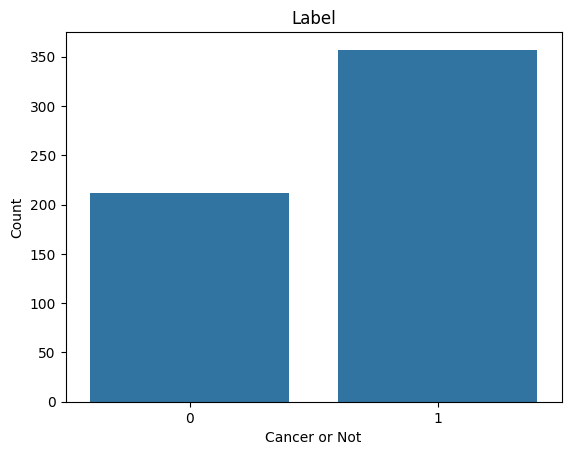

In [7]:
# 레이블 갯수 확인 (그래프)
sns.countplot(data = df, x="label")
plt.xlabel("Cancer or Not")
plt.ylabel("Count")
plt.title("Label")

In [8]:
# 레이블 갯수 확인 (숫자)
df['label'].value_counts()

,count
label,
1,357
0,212


# 결측치 확인 및 제거

In [9]:
# 결측치 확인
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [10]:
# 결측치 제거
df = df.dropna()
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


# 데이터 분포 확인 (컬럼별 히스토그램, 산점도)
- 모델 학습 전, 한 컬럼이 어떤 값들이 어떻게 퍼져있는지 보는 것
  - 데이터 분표 형태 : 학습에 적합한 분포인지
  - 이상치 존재 여부 : 극단값이 있는지
  - 스케일 차이 : 정규화가 필요한지
  - 변수의 유효성 판단 : 학습에 도움되는 특징인지

/tmp/ipykernel_541/2759638331.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['mean radius'], kde = True, hist = False, ax=ax1)
/tmp/ipykernel_541/2759638331.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['mean texture'], ax=ax2)


<Axes: xlabel='mean texture', ylabel='Density'>

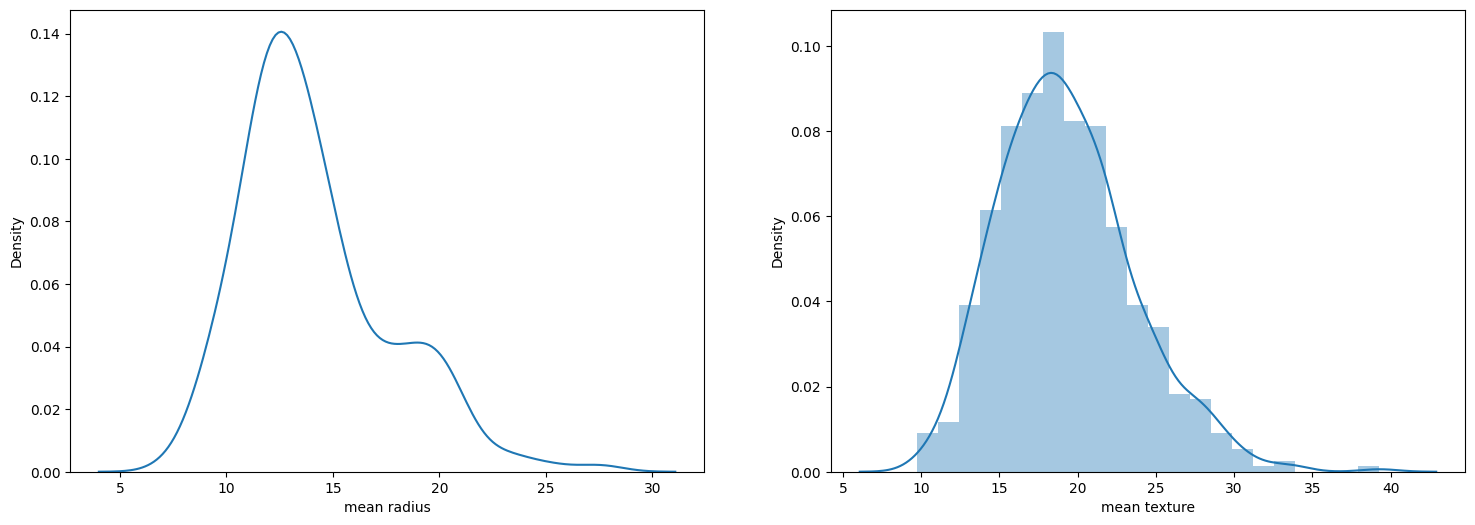

In [11]:
# 컬럼별 히스토그램 확인
# 'mean radius'와'mean texture' 칼럼 선택

figure = plt.figure(figsize=(18,6))

ax1 = plt.subplot(1,2,1)
sns.distplot(df['mean radius'], kde = True, hist = False, ax=ax1)

ax2 = plt.subplot(1,2,2)
sns.distplot(df['mean texture'], ax=ax2)

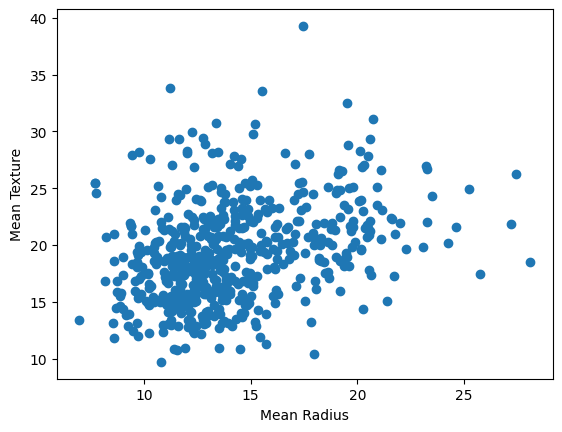

In [12]:
# 산점도 확인

plt.scatter(df['mean radius'], df['mean texture'])
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')

plt.show()

# X / y 설정

In [13]:
X=df.drop('label',axis=1)
X.head()

y=df['label']
y.value_counts()

# 데이터의 처음 5개 행 출력 (default = 5)
y.head()

,label
0,0
1,0
2,0
3,0
4,0


# 원-핫 인코딩
  - 범주형(label)을 모델이 이해할 수 있는 숫자(벡터) 형태로 바꾸는 것
  - why? 모델이 데이터의 순서가 있다고 잘못 해석할 수 있음 > 크기 개념이 없는 독립적인 벡터 형태로 변환
  - when? 분류 문제 + 딥러닝 (특히 Softmax)
  - before
      - [0, 1, 2]  
  - after
    - 0 → [1, 0, 0]  
        1 → [0, 1, 0]  
        2 → [0, 0, 1]

In [14]:
# pd.get_dummies(y) : label을 원-핫 형태로 변환
# .values : pandas → numpy 배열로 변환

Y = pd.get_dummies(y).values

# train / test 데이터 분할

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# 정규화 StandardScaler

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP(Dense) 정의
- 입력 데이터의 여러 특성을 받아, 클래스(label)를 분류하는 신경망 모델
  - 입력: 특성 30개  
중간: Dense layer 여러 개로 특징 조합  
출력: 2개 클래스 확률  
목적: 이진 분류  
- Dense 완전연결층
  - 이전 층의 모든 노드가 다음 층의 모든 노드와 연결되는 층
  - 입력값들을 조합하여 새로운 특징을 생성하는 층
- Activation function 활성화함수
  - 신경망에 비선형성을 추가하여 복잡한 패턴을 학습할 수 있도록 하는 함수
    - ReLU : 주로 은닉층(Dense층)에서 사용 / 음수는 0, 양수는 그대로 출력
     - Sigmoid : 출력층(이진분류) / 출력값을 0~1 사이로 변환
    - Softmax : 출력층(다중분류) / 여러 클래스의 출력값을 확률 분포로 변환 (모든 클래스의 확률의 합 = 1)
- Loss function 손실함수
  - 모델의 예측값과 실제값(정답)의 차이를 수치로 나타내는 함수
  - 출력층에서는 확률 형태로 변환하는 역할도 수행
    - Binary Crossentropy : 이진 분류 문제
    - Categorical Crossentropy : 다중 분류 문제 (원-핫 인코딩된 경우)

In [18]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

# 빈 신경망 모델 생성
model = Sequential()

# 은닉층 생성 : Dense(뉴런수, 입력특성수, 활성화함수)
model.add(Dense(10,input_shape=(30,),activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(2,activation='softmax'))

# 학습 방법 설정 : compile(학습률, 손실함수, 성능확인방법)
model.compile(Adam(learning_rate=0.001),'categorical_crossentropy',metrics=['accuracy'])

# 모델 구조 출력
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 466 (1.82 KB)

 Trainable params: 466 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

# 모델 훈련 및 결과 출력
- 학습 데이터를 이용해 신경망을 훈련시키고 > 테스트 데이터에 대한 예측 결과를 만든 뒤 > 그 결과를 최종 클래스 형태로 바꾸는 코드
  - fit() : 모델 학습  
        predict() : 테스트 데이터 예측  
        argmax() : 확률을 클래스 인덱스로 변환

In [19]:
# 모델 학습
# model_history : 학습 과정 중 기록 저장
# fit(x,y, 전체데이터 30번 반복, 한 번에 32개씩 나눠서, 매 epoch마다 테스트셋으로 성능 확인)
# X_train과 y_train을 보고 가중치를 조금씩 수정하면서 정답을 더 잘 맞추도록 학습
model_history=model.fit(x=X_train, y=y_train, epochs=30, batch_size=32,validation_data= (X_test,y_test))

# 테스트 데이터에 대한 예측값 출력
y_pred = model.predict(X_test)

# 실제값(정답)을 클래스 인덱스로 변환
y_test_class = np.argmax(y_test,axis=1)

# 예측 확률을 최종 클래스 인덱스로 변환
y_pred_class = np.argmax(y_pred,axis=1)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7297 - loss: 0.6608 - val_accuracy: 0.8070 - val_loss: 0.6356
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8725 - loss: 0.5887 - val_accuracy: 0.8684 - val_loss: 0.5348
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9011 - loss: 0.4765 - val_accuracy: 0.8772 - val_loss: 0.4275
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9209 - loss: 0.3713 - val_accuracy: 0.8860 - val_loss: 0.3414
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9385 - loss: 0.2868 - val_accuracy: 0.8860 - val_loss: 0.2810
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9385 - loss: 0.2266 - val_accuracy: 0.9123 - val_loss: 0.2402
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9429 - loss: 0.1873 - val_accuracy: 0.9123 - val_loss: 0.2131
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9495 - loss: 0.1590 - val_accuracy: 0.9211 - val_loss

# Loss(손실값) 변화 그래프
- 노란색: 학습데이터 손실 Training loss
- 빨간색: 검증데이터 손실 Validation loss

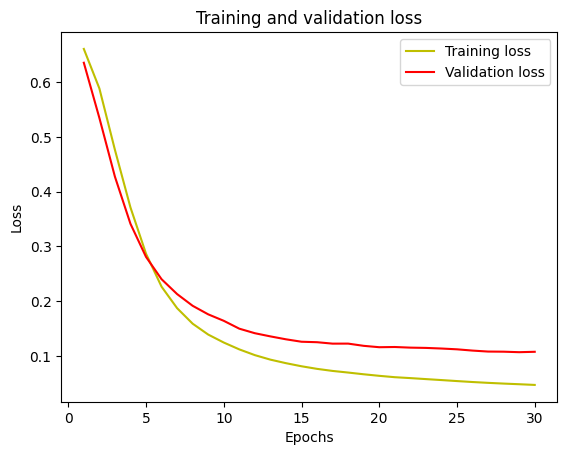

In [20]:
# 학습데이터 손실값 가져오기
loss =model_history.history['loss']
# 검증데이터 손실값 가져오기
val_loss =model_history.history['val_loss']

# epoch 범위 설정 (1~30)
epochs = range(1, len(loss) + 1)

# 그래프 출력
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy(정확도) 변화 그래프
  - 노란색: Training accuracy (학습 데이터 정확도)
  - 빨간색: Validation accuracy (검증 데이터 정확도)

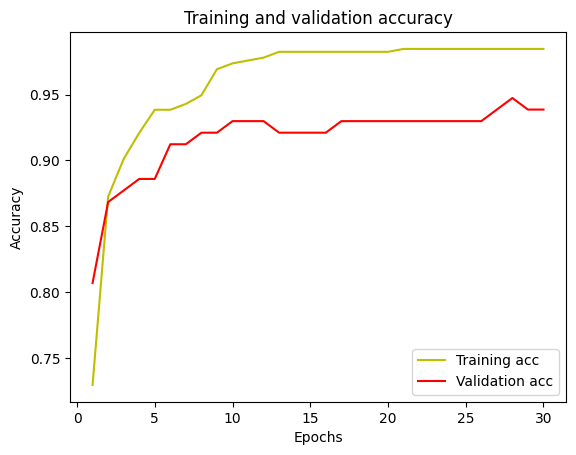

In [22]:
# 학습데이터 정확도
acc =model_history.history['accuracy']
# 검증데이터 정확도
val_acc =model_history.history['val_accuracy']

# 학습데이터 정확도 그래프
plt.plot(epochs, acc, 'y', label='Training acc')
# 검증데이터 정확도 그래프
plt.plot(epochs, val_acc, 'r', label='Validation acc')

# 그래프 그리기
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 모델 성능 평가 Accuracy of the predicted values
- 모델이 얼마나 잘 맞췄는지 구체적으로 분석한 결과
  - precision (정밀도) : 예측값 중 실제 정답은 몇 퍼센트?
  - recall (재현율/민감도) : 실제 정답 중 제대로 예측한 것은 몇 퍼센트?
  - f1 : 균형지표 (precision + recall)
  - accuracy : 최종 정확도


In [25]:
from sklearn.metrics import classification_report,confusion_matrix

# precision, recall, F1-score 출력
print(classification_report(y_test_class,y_pred_class))

# 실제 vs 예측 비교 출력
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        47
           1       0.97      0.93      0.95        67

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.94       114
weighted avg       0.94      0.94      0.94       114

[[45  2]
 [ 5 62]]
